<a href="https://colab.research.google.com/github/e23395/Statistical-Learning-e23395/blob/main/Assignment%205%3A%20Introduction%20to%20Numerical%20Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

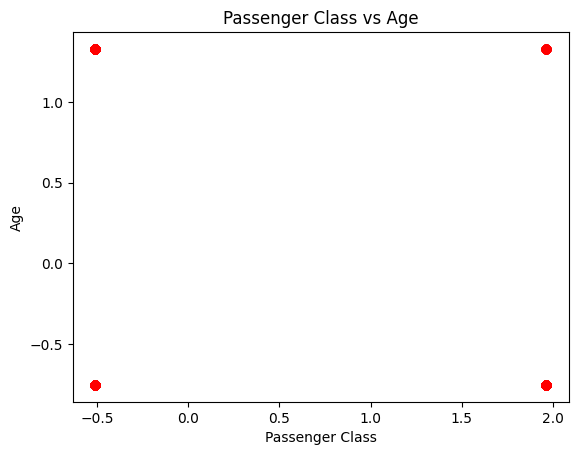

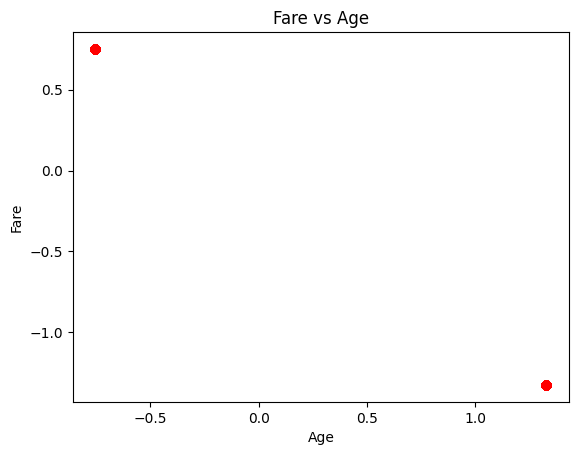

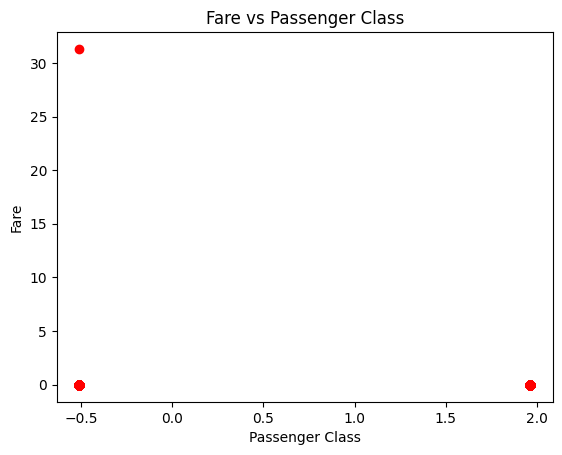

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

'''
Let's import the dataset and take a look. We have the following variables:
Passenger Class, Sex, Age, Fare, and whether or not they survived. Let's make
our indepedent, X, and dependent, y, vectors.

With the first observations we notice a wide range in fare, a number of 'Nan'
values for age, but for the most part nothing looks amiss.
'''
# Importing the dataset
dataset = pd.read_csv('titanic passenger list.csv')
X = dataset.iloc[:, [0,1,2,3,5]].values
y = dataset.iloc[:, 8].values

# Taking care of missing data (lots of missing ages)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean') # Note: missing_values='NaN' might need to be np.nan for newer versions
imputer = imputer.fit(X[:, 2:5])
X[:, 2:5] = imputer.transform(X[:, 2:5])


# Encoding the Independent Variable
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
labelencoder_X = LabelEncoder()
X[:, 1] = labelencoder_X.fit_transform(X[:, 1])
onehotencoder = OneHotEncoder(handle_unknown='ignore') # categorical_features is deprecated, use ColumnTransformer or ensure data type
X = onehotencoder.fit_transform(X).toarray()

# Removing extra dummy variable
X=X[:,1:]

# Splitting the dataset into test and training samples.
from sklearn.model_selection import train_test_split # cross_validation is deprecated
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


# Feature Scaling, note that y doesn't need to be scaled since it's binary
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)
X=sc_X.transform(X)

'''
Visualizations:
'''


# Visualising the Passenger Class vs Age results
plt.scatter(X[:,0], X[:,2], color = 'red')
plt.title('Passenger Class vs Age')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

'''
It looks like 3rd class passengers are younger on average then 2nd class, and
2nd class are younger than 1st class.
'''

# Visualising the Age vs Fare results
plt.scatter(X[:,2], X[:,3], color = 'red')
plt.title('Fare vs Age')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

# Visualising the Passenger Class vs Fare results
plt.scatter(X[:,0], X[:,4], color = 'red')
plt.title('Fare vs Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

'''
It looks like 2nd and 3rd class fares didn't vary nearly as much as the 1st
class fares.  What if I made another pclass, the very rich?
'''



'''
Model: Logistic Regression
79.6% Accuracy
'''

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_logit = confusion_matrix(y_test, y_pred)


'''
Model: SVM-Gaussian
81.4% Accuracy
'''
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state=0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix for SVM model
from sklearn.metrics import confusion_matrix
cm_svm_rbf = confusion_matrix(y_test, y_pred)

'''
Model: SVM-linear
77.7% Accuracy
'''
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear', random_state=0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix for SVM model
from sklearn.metrics import confusion_matrix
cm_svm_linear = confusion_matrix(y_test, y_pred)

'''
Model: Naive Bayes
78.4% Accuracy
'''

from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix for SVM model
from sklearn.metrics import confusion_matrix
cm_nb = confusion_matrix(y_test, y_pred)

'''
Model: Decision Tree
77.7% Accuracy
'''

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_tree = confusion_matrix(y_test, y_pred)

'''
Model: Random Forest w/500 trees
80.5% Accuracy
'''

from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 500, criterion = 'entropy')
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_forest = confusion_matrix(y_test, y_pred)